In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('C:\\Credit-Risk-Model\\data\\credit_train.csv')
df = df.dropna(subset=['default']).reset_index(drop=True)
df

,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,home_ownership,loan_purpose,num_inquiries,savings_balance,months_last_delinq,default
0,59,58822,14317,48,669,13,0,0.2,0.122,MORTGAGE,MEDICAL,2,9438.0,NaN,0
1,49,21461,9006,60,612,8,0,2.8,0.443,MORTGAGE,PERSONAL,1,6223.0,NaN,0
2,35,75417,12004,36,724,13,3,8.3,0.152,RENT,DEBT_CONSOLIDATION,2,4063.0,22.0,0
3,63,133964,7904,48,555,11,0,5.6,0.302,OWN,AUTO,4,2957.0,NaN,0
4,28,134306,6135,48,672,10,0,0.1,0.438,MORTGAGE,MEDICAL,5,385.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,31,91742,34065,36,650,14,0,11.0,0.340,MORTGAGE,PERSONAL,2,3463.0,NaN,0
2996,59,38800,6070,36,756,8,0,2.0,0.253,MORTGAGE,DEBT_CONSOLIDATION,6,1178.0,NaN,0
2997,29,16168,27567,24,601,13,0,3.7,0.151,MORTGAGE,DEBT_CONSOLIDATION,5,20318.0,NaN,1
2998,46,44332,11328,12,625,5,1,9.6,0.095,OWN,PERSONAL,2,2411.0,62.0,0


In [3]:
df['months_last_delinq'] = df['months_last_delinq'].fillna(0)
df['employment_years'] = df['employment_years'].fillna(df['employment_years'].median())
df['savings_balance'] = df['savings_balance'].fillna(df['savings_balance'].median())

df = pd.get_dummies(df, columns=['home_ownership', 'loan_purpose'], drop_first=True, dtype=int)

df['loan_to_income'] = np.where(df['income'] > 0, df['loan_amount'] / df['income'], 0)
df['payment_to_income'] = np.where((df['loan_term'] > 0) & (df['income'] > 0), 
                                   (df['loan_amount'] / df['loan_term']) / df['income'] * 12, 0)
df['credit_utilization_proxy'] = np.where(df['credit_score'] > 0, 
                                          df['num_credit_lines'] / (df['credit_score'] / 100), 0)

df['dti_x_utilization'] = df['debt_to_income'] * df['credit_utilization_proxy']
df['loan_x_dti'] = df['loan_to_income'] * df['debt_to_income']
df['payment_stress'] = df['payment_to_income'] * (df['num_delinquencies'] + 1)
df['savings_to_loan'] = np.where(df['loan_amount'] > 0, df['savings_balance'] / df['loan_amount'], 0)

ratio_cols = ['loan_to_income', 'payment_to_income', 'credit_utilization_proxy', 
              'dti_x_utilization', 'loan_x_dti', 'payment_stress', 'savings_to_loan']
df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], 0).fillna(0)

df

,age,income,loan_amount,loan_term,credit_score,num_credit_lines,num_delinquencies,employment_years,debt_to_income,num_inquiries,...,loan_purpose_HOME_IMPROVEMENT,loan_purpose_MEDICAL,loan_purpose_PERSONAL,loan_to_income,payment_to_income,credit_utilization_proxy,dti_x_utilization,loan_x_dti,payment_stress,savings_to_loan
0,59,58822,14317,48,669,13,0,0.2,0.122,2,...,0,1,0,0.243395,0.060849,1.943199,0.237070,0.029694,0.060849,0.659216
1,49,21461,9006,60,612,8,0,2.8,0.443,1,...,0,0,1,0.419645,0.083929,1.307190,0.579085,0.185903,0.083929,0.690984
2,35,75417,12004,36,724,13,3,8.3,0.152,2,...,0,0,0,0.159168,0.053056,1.795580,0.272928,0.024194,0.212224,0.338471
3,63,133964,7904,48,555,11,0,5.6,0.302,4,...,0,0,0,0.059001,0.014750,1.981982,0.598559,0.017818,0.014750,0.374114
4,28,134306,6135,48,672,10,0,0.1,0.438,5,...,0,1,0,0.045679,0.011420,1.488095,0.651786,0.020008,0.011420,0.062755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,31,91742,34065,36,650,14,0,11.0,0.340,2,...,0,0,1,0.371313,0.123771,2.153846,0.732308,0.126246,0.123771,0.101659
2996,59,38800,6070,36,756,8,0,2.0,0.253,6,...,0,0,0,0.156443,0.052148,1.058201,0.267725,0.039580,0.052148,0.194069
2997,29,16168,27567,24,601,13,0,3.7,0.151,5,...,0,0,0,1.705035,0.852517,2.163062,0.326622,0.257460,0.852517,0.737041
2998,46,44332,11328,12,625,5,1,9.6,0.095,2,...,0,0,1,0.255526,0.255526,0.800000,0.076000,0.024275,0.511053,0.212835


In [5]:
def compute_iv(data, feature, target, bins=10):
    try:
        temp = data[[feature, target]].copy()
        temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        grouped = temp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
        grouped.columns = ['Total', 'Events']
        grouped['Non_Events'] = grouped['Total'] - grouped['Events']
        
        tot_events = grouped['Events'].sum()
        tot_non_events = grouped['Non_Events'].sum()
        
        grouped['Dist_E'] = grouped['Events'] / max(tot_events, 1)
        grouped['Dist_NE'] = grouped['Non_Events'] / max(tot_non_events, 1)
        
        grouped['WoE'] = np.log((grouped['Dist_E'] + 1e-9) / (grouped['Dist_NE'] + 1e-9))
        grouped['IV'] = (grouped['Dist_E'] - grouped['Dist_NE']) * grouped['WoE']
        return grouped['IV'].sum()
    except:
        return 0.0

features_to_test = df.columns.drop('default')
iv_dict = {feat: compute_iv(df, feat, 'default', bins=10) for feat in features_to_test}

selected_features = [feat for feat, iv in iv_dict.items() if iv >= 0.02]
print(f"Selected {len(selected_features)} features.")

Selected 17 features.


In [6]:
X = df[selected_features]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)
y_pred_proba = nn_model.predict_proba(X_test_scaled)[:, 1]

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ks_stat = max(tpr - fpr)
best_idx = np.argmax(tpr - fpr)
best_cutoff = thresholds[best_idx]

print(f"\nNEURAL NETWORK PERFORMANCE")
print(f"AUC Score    : {roc_auc:.4f}")
print(f"KS Statistic : {ks_stat:.4f}")
print(f"Best Cutoff  : {best_cutoff:.4f}\n")


NEURAL NETWORK PERFORMANCE
AUC Score    : 0.5375
KS Statistic : 0.0950
Best Cutoff  : 0.4523



In [8]:
y_arr = np.array(y_test)
cutoffs = np.arange(0.10, 0.91, 0.05)
results = []

for c in cutoffs:
    pred_c = (y_pred_proba >= c).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_arr, pred_c, labels=[0,1]).ravel()
    
    appr_rate = (tn + fn) / len(y_arr) * 100
    def_rate_appr = fn / max(tn + fn, 1) * 100
    tot_profit = (tn * 10) + (fn * -70) + ((tp + fp) * -2)
    profit_per_loan = tot_profit / len(y_arr)
    
    results.append([c, appr_rate, def_rate_appr, tot_profit, profit_per_loan])

res_df = pd.DataFrame(results, columns=['Cutoff', 'Approval_Rate', 'Default_Rate', 'Total_Profit', 'Profit_per_Loan'])

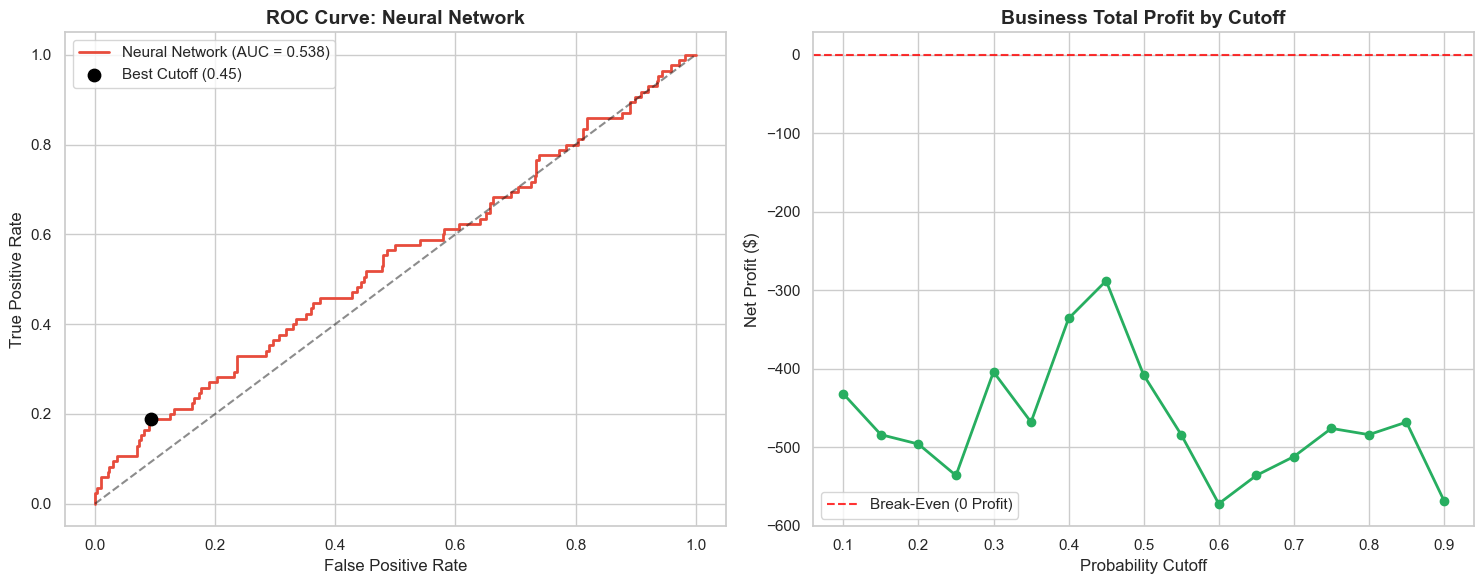

 --- Top 5 Profitable Cutoffs ---
 Cutoff  Approval_Rate  Default_Rate  Total_Profit  Profit_per_Loan
   0.45          89.33         12.87          -288            -0.48
   0.40          88.67         12.97          -336            -0.56
   0.30          85.50         13.06          -404            -0.67
   0.50          91.00         13.19          -408            -0.68
   0.10          74.00         12.84          -432            -0.72


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(fpr, tpr, label=f'Neural Network (AUC = {roc_auc:.3f})', color='#e74c3c', lw=2)
axes[0].scatter(fpr[best_idx], tpr[best_idx], color='black', s=80, label=f'Best Cutoff ({best_cutoff:.2f})', zorder=5)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve: Neural Network', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(res_df['Cutoff'], res_df['Total_Profit'], marker='o', color='#27ae60', lw=2)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.8, label='Break-Even (0 Profit)')
axes[1].set_title('Business Total Profit by Cutoff', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Probability Cutoff')
axes[1].set_ylabel('Net Profit ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(" --- Top 5 Profitable Cutoffs ---")
print(res_df.sort_values('Total_Profit', ascending=False).head(5).round(2).to_string(index=False))